## Import Libraries and Load Data

In [1]:
# Load core libraries and read the Hotazel Steam dataset into a dataframe

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')


## Review the Dataset

In [2]:
# Display the full dataset to confirm structure, column names and date range before any analysis

display(HS_data)


,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


## Visualize Monthly Revenue Over Time

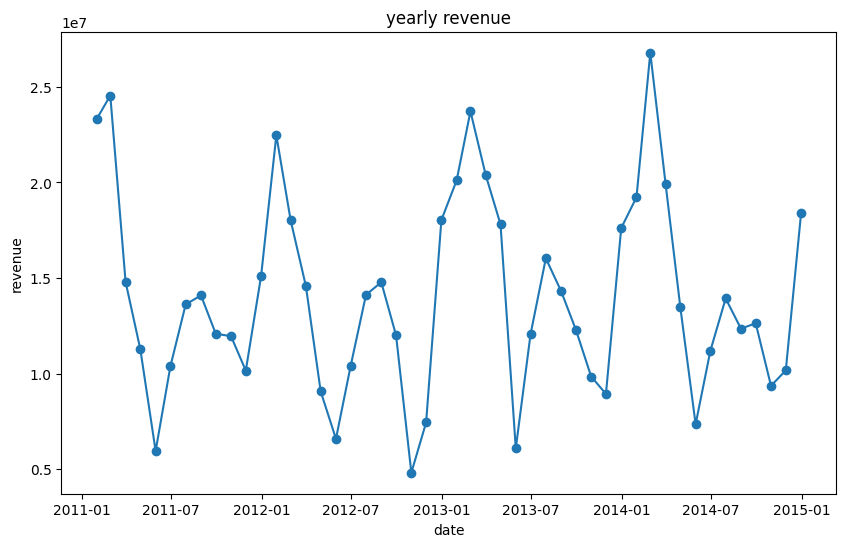

In [3]:
# Convert date column to datetime format then plot monthly revenue to identify
# seasonal patterns and trends before modelling

# Step 0: make sure your dates are recognized as dates
HS_data['date'] = pd.to_datetime(HS_data['date'])

plt.figure(figsize=(10,6))

plt.title('yearly revenue')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(HS_data['date'], HS_data['revenue'], marker='o')


## Correlation Analysis

In [4]:
# Calculate correlation coefficients between revenue and all potential independent variables
# to identify which are most strongly associated and worth including in the model

HS_data.loc[:,['revenue','production','coolDD','heatDD']].corr()


,revenue,production,coolDD,heatDD
revenue,1.000000,0.632091,-0.169433,0.686901
production,0.632091,1.000000,0.509203,0.032060
coolDD,-0.169433,0.509203,1.000000,-0.716721
heatDD,0.686901,0.032060,-0.716721,1.000000


## Split into Training and Testing Sets

In [5]:
# Separate data into training (2011 to 2013) and testing (2014) sets
# The model will be built on training data only and evaluated on testing data it has never seen

dt4training = HS_data.loc[HS_data['type']=='dt4training']
dt4testing = HS_data.loc[HS_data['type']=='dt4testing']

display(dt4testing)


,type,date,revenue,production,coolDD,heatDD
36,dt4testing,2014-01-31,19228840,606400,0,1123
37,dt4testing,2014-02-28,26792280,714128,0,938
38,dt4testing,2014-03-31,19935840,805600,0,866
39,dt4testing,2014-04-30,13468000,375856,0,412
40,dt4testing,2014-05-31,7344128,279296,49,88
41,dt4testing,2014-06-30,11196216,517600,230,0
42,dt4testing,2014-07-31,13929472,749472,380,0
43,dt4testing,2014-08-31,12352176,663432,322,0
44,dt4testing,2014-09-30,12628944,701656,178,14
45,dt4testing,2014-10-31,9361000,411728,24,166


## Build Model: Production as Independent Variable

In [6]:
# Define revenue as the dependent variable and production as the independent variable
# Add a constant for the intercept then fit an OLS regression model on the training set

import statsmodels.api as sm

y = dt4training.loc[:,'revenue']

x = dt4training.loc[:,'production']
x = sm.add_constant(x)

model1 = sm.OLS(y,x).fit()

pd.options.display.float_format = '{:.2f}'.format

model1.params


,0
const,4897663.26
production,18.99


## Model Equation

revenue = 18.99 * production + 4,897,663

## Forecast on Testing Data

In [7]:
# Prepare the testing set independent variable and generate predicted revenue values using the trained model

x_test = dt4testing.loc[:,'production']
x_test = sm.add_constant(x_test)

model1.predict(x_test)


,0
36,16414428.69
37,18460401.82
38,20197640.55
39,12035930.72
40,10202060.55
41,14727936.65
42,19131656.04
43,17497582.00
44,18223533.25
45,12717212.73


## Calculate MAPE

In [8]:
# Copy the testing dataframe and attach predicted values
# Calculate the percentage error for each month as the basis for the MAPE score

model1_assessment = dt4testing.copy()

model1_assessment['model1_predicted_revenue'] = model1.predict(x_test)

model1_assessment['pct_error'] = abs((model1_assessment['revenue'] - model1_assessment['model1_predicted_revenue']
                                  )/model1_assessment['revenue'])

display(model1_assessment)


,type,date,revenue,production,coolDD,heatDD,model1_predicted_revenue,pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,16414428.69,0.15
37,dt4testing,2014-02-28,26792280,714128,0,938,18460401.82,0.31
38,dt4testing,2014-03-31,19935840,805600,0,866,20197640.55,0.01
39,dt4testing,2014-04-30,13468000,375856,0,412,12035930.72,0.11
40,dt4testing,2014-05-31,7344128,279296,49,88,10202060.55,0.39
41,dt4testing,2014-06-30,11196216,517600,230,0,14727936.65,0.32
42,dt4testing,2014-07-31,13929472,749472,380,0,19131656.04,0.37
43,dt4testing,2014-08-31,12352176,663432,322,0,17497582.00,0.42
44,dt4testing,2014-09-30,12628944,701656,178,14,18223533.25,0.44
45,dt4testing,2014-10-31,9361000,411728,24,166,12717212.73,0.36


## MAPE Score

In [9]:
# Average the absolute percentage errors across all testing months to produce the final MAPE score
# Lower MAPE indicates a more accurate model

model1_assessment['pct_error'].mean()


np.float64(0.2542315606071484)

## Visualize Actual vs Predicted Revenue

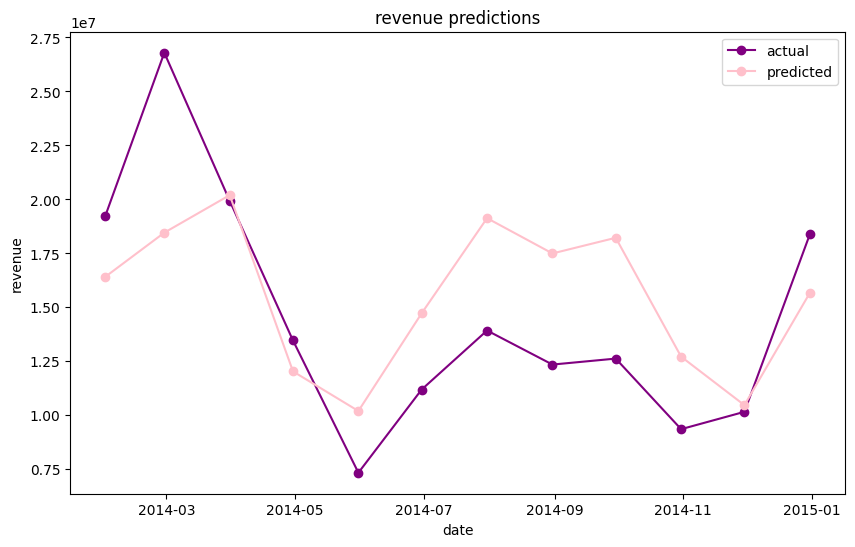

In [10]:
# Plot actual versus predicted revenue over the testing period to visually assess
# how closely the model tracks real outcomes

plt.figure(figsize=(10,6))

plt.title('revenue predictions')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(model1_assessment['date'],model1_assessment['revenue'],marker='o', color='purple', label='actual')
plt.plot(model1_assessment['date'],model1_assessment['model1_predicted_revenue'],marker='o', color='pink', label='predicted')
plt.legend()
